Import Library

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns


Load Dataset

In [28]:
url = '/content/RegresiUTSTelkom.csv'
data = pd.read_csv(url)

In [6]:
print(data.head())

   2001  49.94357  21.47114   73.0775   8.74861  -17.40628  -13.09905  \
0  2001  48.73215  18.42930  70.32679  12.94636  -10.32437  -24.83777   
1  2001  50.95714  31.85602  55.81851  13.41693   -6.57898  -18.54940   
2  2001  48.24750  -1.89837  36.29772   2.58776    0.97170  -26.21683   
3  2001  50.97020  42.20998  67.09964   8.46791  -15.85279  -16.81409   
4  2001  50.54767   0.31568  92.35066  22.38696  -25.51870  -19.04928   

   -25.01202  -12.23257   7.83089  ...   13.0162  -54.40548  58.99367  \
0    8.76630   -0.92019  18.76548  ...   5.66812  -19.68073  33.04964   
1   -3.27872   -2.35035  16.07017  ...   3.03800   26.05866 -50.92779   
2    5.05097  -10.34124   3.55005  ...  34.57337 -171.70734 -16.96705   
3  -12.48207   -9.37636  12.63699  ...   9.92661  -55.95724  64.92712   
4   20.67345   -5.19943   3.63566  ...   6.59753  -50.69577  26.02574   

   15.37344   1.11144  -23.08793   68.40795  -1.82223  -27.46348   2.26327  
0  42.87836  -9.90378  -32.22788   70.49388  

In [7]:
print(f"Missing values in each column:\n{data.isnull().sum()}")


Missing values in each column:
2001         0
49.94357     0
21.47114     0
73.0775      0
8.74861      0
            ..
-23.08793    1
68.40795     1
-1.82223     1
-27.46348    1
2.26327      1
Length: 91, dtype: int64


In [8]:
print(f"Missing values in each column:\n{data.isnull().sum()}")

Missing values in each column:
2001         0
49.94357     0
21.47114     0
73.0775      0
8.74861      0
            ..
-23.08793    1
68.40795     1
-1.82223     1
-27.46348    1
2.26327      1
Length: 91, dtype: int64


In [9]:
data.dropna(inplace=True)


Data Preprocessing

In [10]:
data.columns = ['Year', 'Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6',
                'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11', 'Feature12', 'Feature13',
                'Feature14', 'Feature15', 'Feature16', 'Feature17', 'Feature18', 'Feature19', 'Feature20',
                'Feature21', 'Feature22', 'Feature23', 'Feature24', 'Feature25', 'Feature26', 'Feature27',
                'Feature28', 'Feature29', 'Feature30', 'Feature31', 'Feature32', 'Feature33', 'Feature34',
                'Feature35', 'Feature36', 'Feature37', 'Feature38', 'Feature39', 'Feature40', 'Feature41',
                'Feature42', 'Feature43', 'Feature44', 'Feature45', 'Feature46', 'Feature47', 'Feature48',
                'Feature49', 'Feature50', 'Feature51', 'Feature52', 'Feature53', 'Feature54', 'Feature55',
                'Feature56', 'Feature57', 'Feature58', 'Feature59', 'Feature60', 'Feature61', 'Feature62',
                'Feature63', 'Feature64', 'Feature65', 'Feature66', 'Feature67', 'Feature68', 'Feature69',
                'Feature70', 'Feature71', 'Feature72', 'Feature73', 'Feature74', 'Feature75', 'Feature76',
                'Feature77', 'Feature78', 'Feature79', 'Feature80', 'Feature81', 'Feature82', 'Feature83',
                'Feature84', 'Feature85', 'Feature86', 'Feature87', 'Feature88', 'Feature89', 'Feature90']


Set Target and Features

In [11]:
target_column = 'Year'  # Set target column to 'Year'
X = data.drop(columns=[target_column])  # Features (excluding target)
y = data[target_column]  # Target (Year)

Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


 Feature Scaling

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


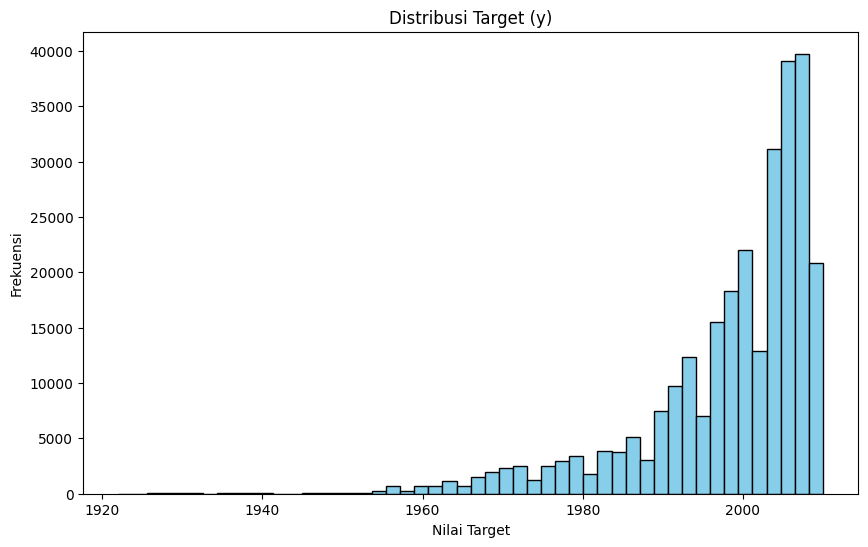

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(y, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribusi Target (y)')
plt.xlabel('Nilai Target')
plt.ylabel('Frekuensi')
plt.show()


In [16]:
y_scaled = (y - y.mean()) / y.std()
y_train = y_scaled.loc[X_train.index]
y_test = y_scaled.loc[X_test.index]


Build the MLP Model Using Keras

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),  # Menambah layer lebih besar
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer untuk regresi
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train the Model

In [18]:
history = model.fit(X_train_scaled, y_train, epochs=10, validation_split=0.2, batch_size=32)

Epoch 1/10
5534/5534 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 0.7318 - mae: 0.5988 - val_loss: 0.6546 - val_mae: 0.5591
Epoch 2/10
5534/5534 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - loss: 0.6455 - mae: 0.5556 - val_loss: 0.6422 - val_mae: 0.5492
Epoch 3/10
5534/5534 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.6212 - mae: 0.5438 - val_loss: 0.6279 - val_mae: 0.5425
Epoch 4/10
5534/5534 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.6044 - mae: 0.5354 - val_loss: 0.6273 - val_mae: 0.5463
Epoch 5/10
5534/5534 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.5798 - mae: 0.5255 - val_loss: 0.6281 - val_mae: 0.5397
Epoch 6/10
5534/5534 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 0.5548 - mae: 0.5148 - val_loss: 0.6236 - val_mae: 0.5383
Epoch 7/10
5534/5534 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - loss: 0.5251 - mae: 0.5022 - val_loss: 0.6479 - val_mae: 0.5498
Epoch 8/10
5534/5534 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 0.5070 - mae: 0.4944 - val_loss: 0.6700 - val_mae: 0.5528
Epoch 9/10
5534/5534 ━━━━━━━━━━━

Evaluate the Model

In [19]:
y_pred = model.predict(X_test_scaled)

1730/1730 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [20]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-Squared: {r_squared}")


Mean Squared Error (MSE): 0.6660103675319218
Root Mean Squared Error (RMSE): 0.81609458246696
R-Squared: 0.33893494520698064


Visualize Predicted vs Actual Values

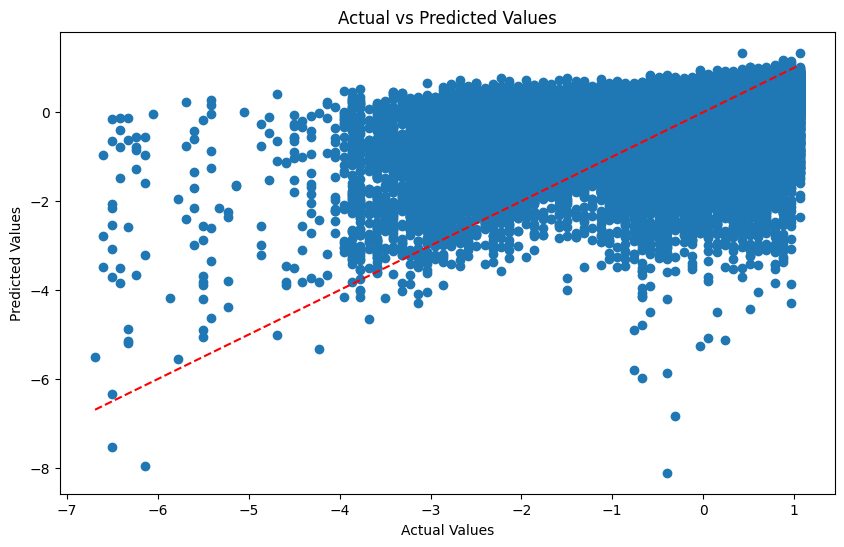

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()


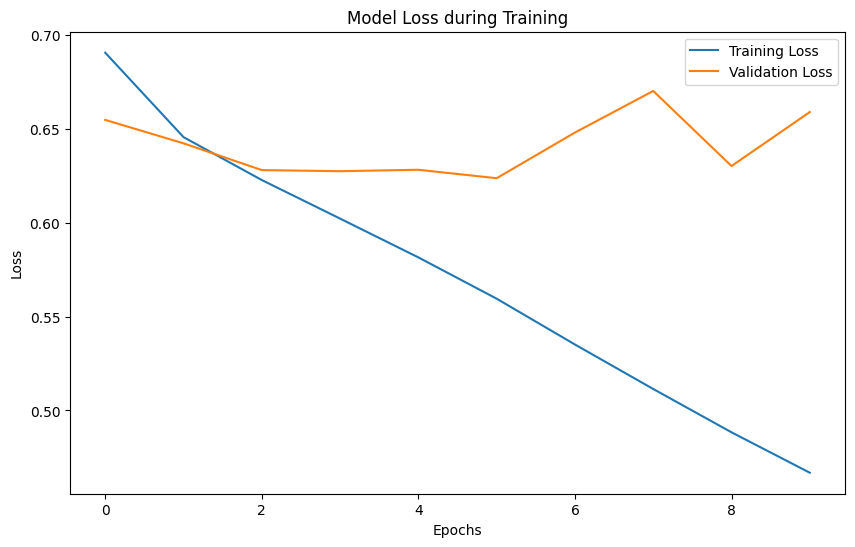

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss during Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [23]:
print(y_test.value_counts())

Year
 0.787865    4187
 0.696631    3987
 0.605397    3859
 0.879099    3691
 0.970333    3264
             ... 
-6.054672       1
-5.872204       1
-6.693309       1
-5.324801       1
-5.051100       1
Name: count, Length: 84, dtype: int64


In [24]:
y_pred_class = (y_pred > 0.5).astype(int)

Evaluasi Matriks

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_test_class = (y_test > 0.5).astype(int)
y_pred_class = (y_pred > 0.5).astype(int)

accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class, zero_division=1)
recall = recall_score(y_test_class, y_pred_class, zero_division=1)
f1 = f1_score(y_test_class, y_pred_class, zero_division=1)
roc_auc = roc_auc_score(y_test_class, y_pred_class)

print("\n" + "="*50)
print("          Classification Metrics".center(50))
print("="*50)

print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-Score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")

print("="*50)



                   Classification Metrics         
Accuracy     : 0.6935
Precision    : 0.7298
Recall       : 0.4261
F1-Score     : 0.5381
ROC-AUC      : 0.6562


AUC ROC

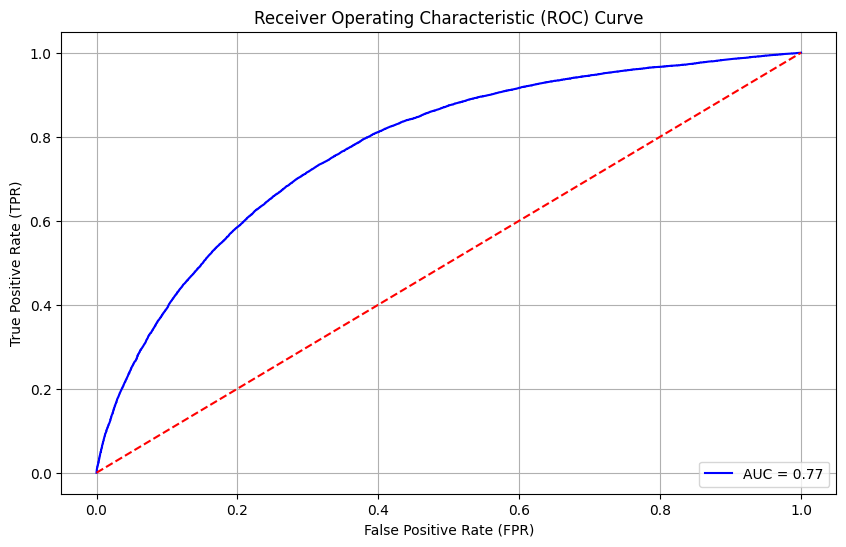

In [26]:
# AUC-ROC: Calculate AUC-ROC based on predicted probabilities (not binary)
roc_auc = roc_auc_score(y_test_class, y_pred)
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_class, y_pred)  # y_pred contains continuous probabilities

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Visualisasi Confusion Matrix

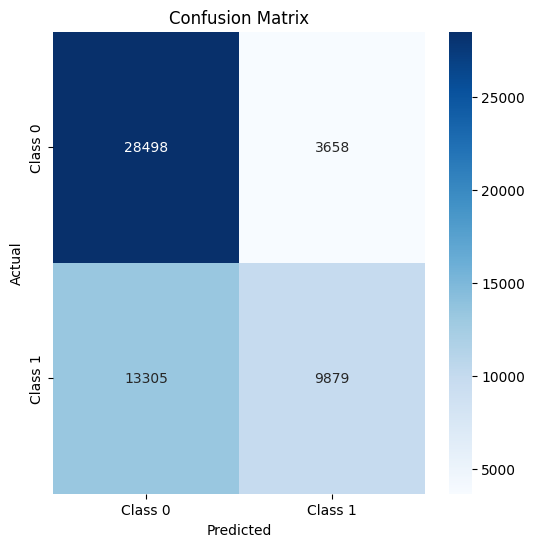

In [27]:
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
